In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
#data loading 
import pandas as pd
DATA_PATH = "/kaggle/input/datasets/javeriaismail99/iris-species/Iris.csv"
df = pd.read_csv(DATA_PATH)
print(df.shape); print(df.head())

(150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


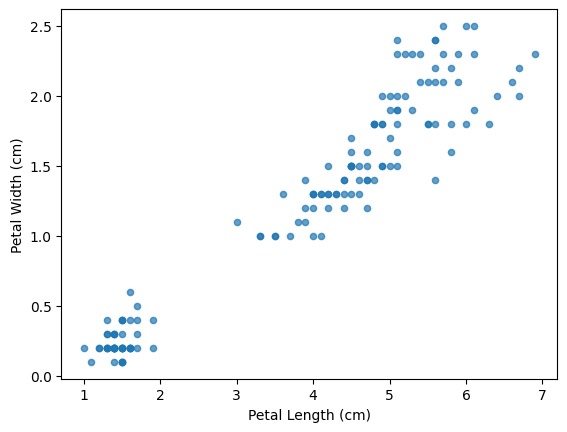

In [2]:
#visualization 
import matplotlib.pyplot as plt
plt.scatter(df["PetalLengthCm"], df["PetalWidthCm"], s=20, alpha=0.7)
plt.xlabel("Petal Length (cm)"); plt.ylabel("Petal Width (cm)"); plt.show()

In [4]:
#preprocessing
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = df[feature_cols].values

In [11]:
#training
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [12]:
#testing
df["Cluster"] = kmeans.predict(X)
print(df["Cluster"].value_counts())

Cluster
0    62
1    50
2    38
Name: count, dtype: int64


In [13]:
#validate
comparison = pd.crosstab(df["Cluster"], df["Species"])
print(comparison)

Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               48              14
1                 50                0               0
2                  0                2              36
